In [70]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# import data clened

df = pd.read_csv("../data/clean_data/dataset_clean.csv")

## One-Hot Encoder

In [71]:
categorical_columns = [
    "Gender",
    "School_Type",
    "Extracurricular_Activities",
    "Internet_Access",
    "Learning_Disabilities",
    "Peer_Influence"
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = encoder.fit_transform(df[categorical_columns])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_columns)
).astype(int)

encoded_df

,Gender_Female,Gender_Male,School_Type_Private,School_Type_Public,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Learning_Disabilities_No,Learning_Disabilities_Yes,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive
0,0,1,0,1,1,0,0,1,1,0,0,0,1
1,1,0,0,1,1,0,0,1,1,0,1,0,0
2,0,1,0,1,0,1,0,1,1,0,0,1,0
3,0,1,0,1,0,1,0,1,1,0,1,0,0
4,1,0,0,1,0,1,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6498,1,0,0,1,1,0,0,1,1,0,0,0,1
6499,1,0,0,1,1,0,0,1,1,0,0,0,1
6500,1,0,0,1,0,1,0,1,1,0,1,0,0
6501,1,0,1,0,0,1,0,1,1,0,0,0,1


## Encodage ordinal

In [72]:
ordinal_columns = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
]

categories = [
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['High School', 'College', 'Postgraduate'],
    ['Near', 'Moderate', 'Far']
]

encoder = OrdinalEncoder(categories=categories)

encoded = encoder.fit_transform(df[ordinal_columns]).astype(int)

encoded_df[ordinal_columns] = encoded

encoded_df

,Gender_Female,Gender_Male,School_Type_Private,School_Type_Public,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Learning_Disabilities_No,Learning_Disabilities_Yes,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality,Parental_Education_Level,Distance_from_Home
0,0,1,0,1,1,0,0,1,1,0,0,0,1,0,2,0,0,1,0,0
1,1,0,0,1,1,0,0,1,1,0,1,0,0,0,1,0,1,1,1,1
2,0,1,0,1,0,1,0,1,1,0,0,1,0,1,1,1,1,1,2,0
3,0,1,0,1,0,1,0,1,1,0,1,0,0,0,1,1,1,1,0,1
4,1,0,0,1,0,1,0,1,1,0,0,1,0,1,1,1,1,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6498,1,0,0,1,1,0,0,1,1,0,0,0,1,2,1,1,2,1,0,0
6499,1,0,0,1,1,0,0,1,1,0,0,0,1,2,1,1,0,2,0,0
6500,1,0,0,1,0,1,0,1,1,0,1,0,0,1,0,0,0,1,2,0
6501,1,0,1,0,0,1,0,1,1,0,0,0,1,2,2,2,0,1,0,2


## the correlation matrix after encoding

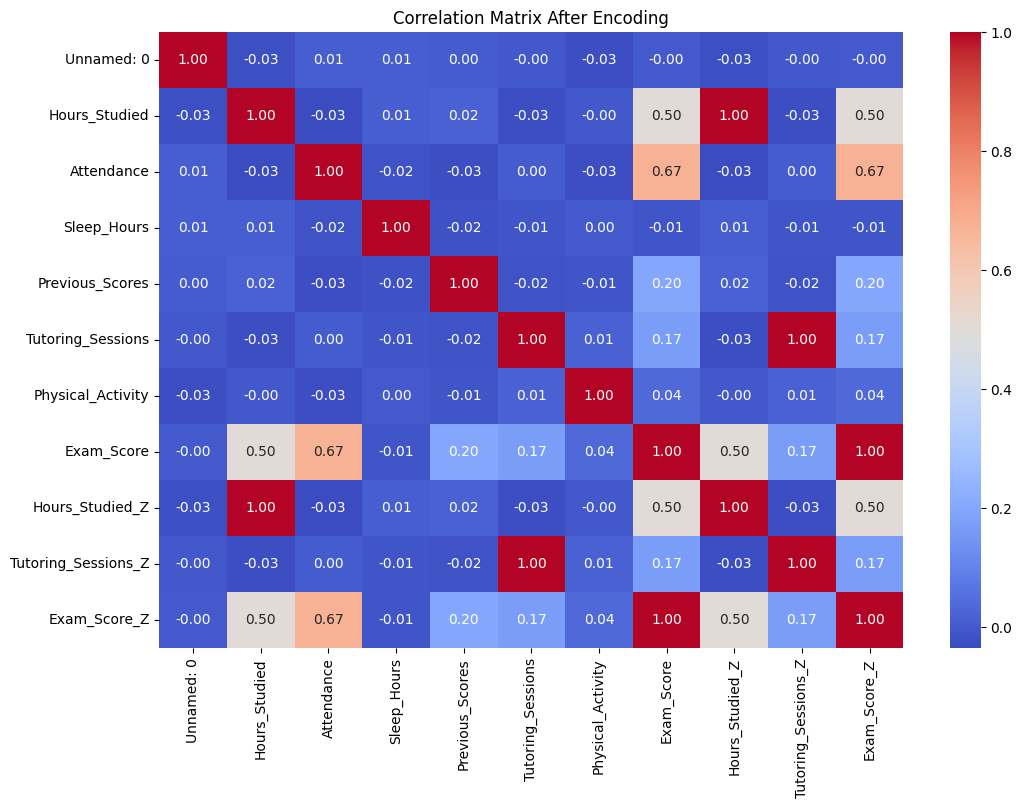

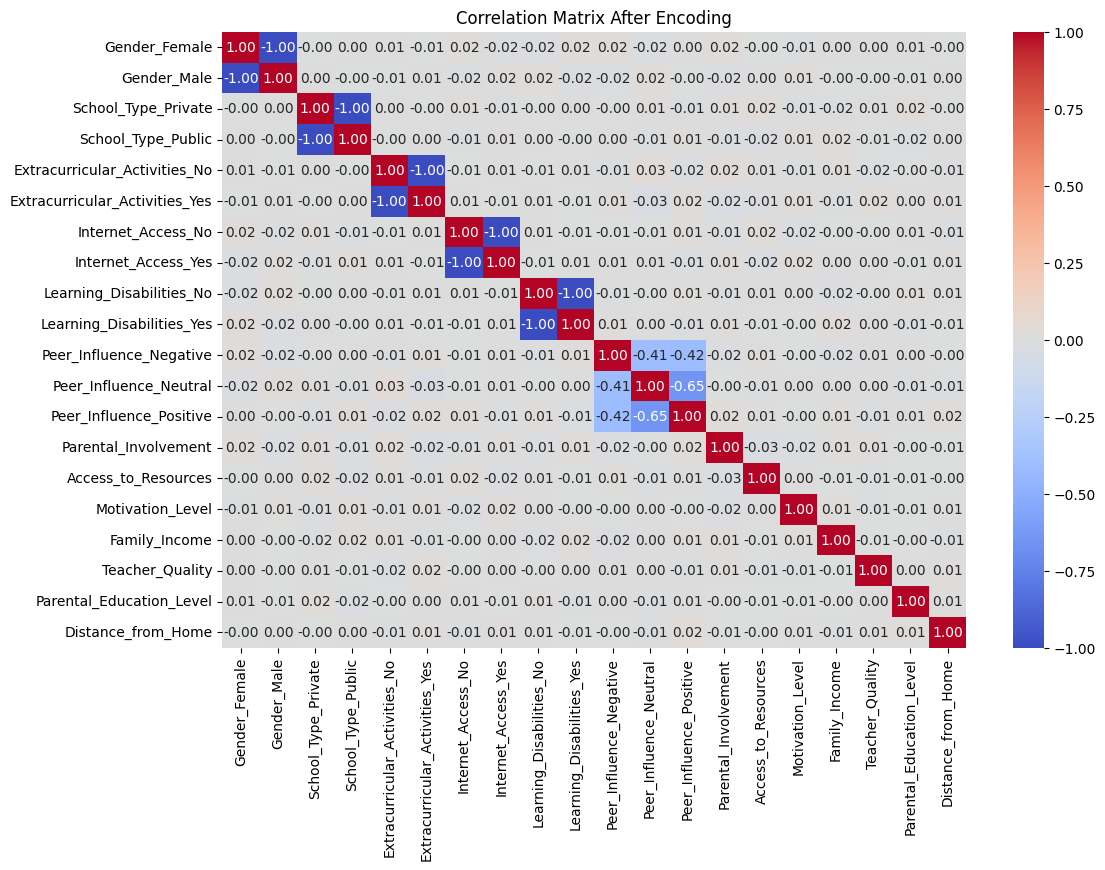

In [73]:

correlation_matrix = encoded_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix After Encoding')
plt.show()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix After Encoding')
plt.show()

## 80/20 Train-Test Split and Standard Scaling of Numerical Variables

In [74]:
numerical_columns = [
    'Hours_Studied',
    'Attendance',
    'Previous_Scores',
    'Sleep_Hours',
    'Tutoring_Sessions',
    'Physical_Activity'
]

X = pd.concat([df[numerical_columns],encoded_df], axis=1)
Y = df['Exam_Score']

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

scaler.fit(X_train[numerical_columns])

X_train[numerical_columns] = scaler.transform(X_train[numerical_columns])

X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])


In [75]:
# # train the actual ML model
#
# model = LinearRegression()
# model.fit(X_train, Y_train)
#
# # Make predictions
#
#
# y_pred = model.predict(X_test)
#
# print(r2_score(Y_test, y_pred))
#
# r2 = r2_score(Y_test, y_pred)
# mae = mean_absolute_error(Y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
#
# print("R²:", r2)
# print("MAE:", mae)
# print("RMSE:", rmse)

## train 4 models

In [81]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(random_state=42))
    ]),

    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBRegressor(random_state=42))
    ]),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR())
    ])
}

for name, pipeline in models.items():
    pipeline.fit(X_train, Y_train)

for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)



Linear Regression

0.9897167958563372
R²: 0.9897167958563372
MAE: 0.27176268219342914
RMSE: 0.32715110989442414

Random Forest

0.8916730864988169
R²: 0.8916730864988169
MAE: 0.840499615680246
RMSE: 1.0618235514527246

XGBoost

0.9565138816833496
R²: 0.9565138816833496
MAE: 0.5311801831232961
RMSE: 0.6727588650756342

SVR

0.9718423298825807
R²: 0.9718423298825807
MAE: 0.4036589469485146
RMSE: 0.5413554677461802


## evaluate the baselines with RMSE, MAE, and R² and build the result in DataFeame and save it

In [87]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return r2, mae, rmse
results = []
for name, pipeline in models.items():
    pipeline.fit(X_train, Y_train)
    r2, mae, rmse = evaluate(pipeline, X_test, Y_test)

    results.append({
        "Model": name,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"\n{name}\n")
    print("R²:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)

results_df = pd.DataFrame(results)

results_df.to_csv('../data/results/baseline.csv')


Linear Regression

R²: 0.9897167958563372
MAE: 0.27176268219342914
RMSE: 0.32715110989442414

Random Forest

R²: 0.8916730864988169
MAE: 0.840499615680246
RMSE: 1.0618235514527246

XGBoost

R²: 0.9565138816833496
MAE: 0.5311801831232961
RMSE: 0.6727588650756342

SVR

R²: 0.9718423298825807
MAE: 0.4036589469485146
RMSE: 0.5413554677461802
